In [1]:
import pandas as pd
import numpy as np

# --- NOTATKA: FUNKCJA POMOCNICZA ---
# Na kolokwium warto pamiętać, że pandas podaje rozmiary w bajtach.
# Aby wynik był czytelny, stosujemy dzielenie przez 1024 (jednostki binarne).
def sizeof_fmt(num, suffix="B"):
    # Jednostki z "i" (KiB, MiB) oznaczają wielokrotności 1024, a nie 1000.
    for unit in ("", "Ki", "Mi", "Gi", "Ti", "Pi", "Ei", "Zi"):
        if abs(num) < 1024.0:
            return f"{num:3.1f}{unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f}Yi{suffix}"

# --- ZADANIE 1 ---

# 1. Wczytanie danych
# PAMIĘTAJ: Pliki .parquet są formatem kolumnowym i zazwyczaj są już skompresowane.
# Po wczytaniu do RAM ich rozmiar znacznie wzrośnie, bo pandas rozpakuje je do "surowych" typów.
df = pd.read_parquet('0000.parquet')

print("--- Ogólne informacje o ramce ---")
df.info()

# 3. Dokładny pomiar pamięci RAM
# Metoda memory_usage() zwraca zużycie dla każdej kolumny w bajtach.
# KLUCZOWY PARAMETR: deep=True
# Bez deep=True pandas policzy tylko wagę "wskazań" (pointerów) do tekstów, a nie same teksty.
# Z deep=True zagląda głęboko do pamięci i podaje prawdziwy rozmiar (np. opisów postów czy bio).
usage_per_column = df.memory_usage(deep=True)
total_usage = usage_per_column.sum()

print("\n--- DOKŁADNY POMIAR (Notatki na kolokwium) ---")
print(f"Łączne zużycie RAM: {sizeof_fmt(total_usage)}")
print("-" * 30)

# 4. Analiza poszczególnych kolumn
# To pozwoli wskazać w Zadaniu 2, które kolumny "kradną" najwięcej RAMu.
for col, memory in usage_per_column.items():
    print(f"Kolumna: {col:20} | Rozmiar: {sizeof_fmt(memory)}")


# - Kolumnę 'object', która waży dużo (np. date, lang, category) -> kandydat do zmiany na datetime lub category.
# - Kolumnę 'int64', która waży 8.8MiB -> sprawdź czy wartości nie zmieszczą się w int16 lub int32 (downcasting).
# - Kolumnę 'bool', która waży 1.1MiB -> to najlżejszy typ, zazwyczaj nie wymaga poprawki.

--- Ogólne informacje o ramce ---
<class 'pandas.DataFrame'>
RangeIndex: 1147358 entries, 0 to 1147357
Data columns (total 17 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   sid                  1147358 non-null  int64
 1   sid_profile          1147358 non-null  int64
 2   post_id              1147358 non-null  str  
 3   profile_id           1147358 non-null  int64
 4   date                 1147358 non-null  str  
 5   post_type            1147358 non-null  int64
 6   description          1147358 non-null  str  
 7   likes                1147358 non-null  int64
 8   comments             1147358 non-null  int64
 9   username             1147358 non-null  str  
 10  bio                  1027403 non-null  str  
 11  following            1147358 non-null  int64
 12  followers            1147358 non-null  int64
 13  num_posts            1147358 non-null  int64
 14  is_business_account  1147358 non-null  bool 
 15  lang     

Pamięć 'przed': 536.6MiB
Pamięć 'po': 441.9MiB
Udało się urwać: 17.6% pamięci RAM!


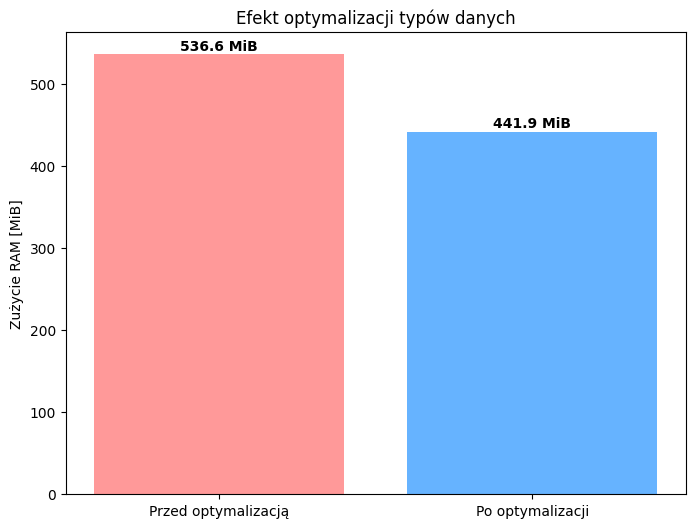

In [2]:
import matplotlib.pyplot as plt

# --- ZADANIE 2 ---
mem_before = df.memory_usage(deep=True).sum()

# --- OPTYMALIZACJA TYPÓW ---

# 2. Daty: Zamiast ciężkich napisów (object), dajemy datetime.
df['date'] = pd.to_datetime(df['date'])

# Zamiast trzymać milion razy "en" albo "music", trzymamy to raz w słowniku.
df['lang'] = df['lang'].astype('category')
df['category'] = df['category'].astype('category')

# 4. Downcasting: funkcja, która sprawdza zakres liczb i obcina je z int64 na np. int16.
# Robimy to dla wszystkich ID-ków i liczników (lajki, komcie itp.).
numeric_cols = ['sid', 'sid_profile', 'profile_id', 'post_type', 'likes',
                'comments', 'following', 'followers', 'num_posts']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], downcast='integer')

mem_after = df.memory_usage(deep=True).sum()

print(f"Pamięć 'przed': {sizeof_fmt(mem_before)}")
print(f"Pamięć 'po': {sizeof_fmt(mem_after)}")


zysk = 100 * (mem_before - mem_after) / mem_before
print(f"Udało się urwać: {zysk:3.1f}% pamięci RAM!")


plt.figure(figsize=(8, 6))
labels = ['Przed optymalizacją', 'Po optymalizacji']
values = [mem_before / (1024**2), mem_after / (1024**2)] # Przeliczamy na MiB

plt.bar(labels, values, color=['#ff9999','#66b3ff'])
plt.ylabel('Zużycie RAM [MiB]')
plt.title('Efekt optymalizacji typów danych')

for i, v in enumerate(values):
    plt.text(i, v + 5, f"{v:.1f} MiB", ha='center', fontweight='bold')

plt.show()

In [3]:
from datetime import datetime

# --- ZADANIE 3 ---

df_orig = pd.read_parquet('0000.parquet')

def run_benchmarks(data, label):
    print(f"\n--- Testy dla: {label} ---")

    # TEST 1: Grupowanie i agregacja
    # Sprawdzamy średnią liczbę lajków dla każdej kategorii
    start = datetime.now()
    res1 = data.groupby('category', observed=True)['likes'].mean()
    time1 = datetime.now() - start
    print(f"1. Grupowanie (mean): {time1}")

    # TEST 2: Filtrowanie
    # Szukamy popularnych postów w konkretnym języku
    start = datetime.now()
    res2 = data[(data['likes'] > 1000) & (data['lang'] == 'en')]
    time2 = datetime.now() - start
    print(f"2. Filtrowanie:      {time2}")

    # TEST 3: Sortowanie
    # Sortujemy po liczbie komentarzy, żeby zobaczyć co najbardziej angażuje
    start = datetime.now()
    res3 = data.sort_values(by='comments', ascending=False)
    time3 = datetime.now() - start
    print(f"3. Sortowanie:       {time3}")

    return time1, time2, time3

t_orig = run_benchmarks(df_orig, "DANE ORYGINALNE (Ciężkie)")
t_opt = run_benchmarks(df, "DANE ZOPTYMALIZOWANE (Lekkie)")

# --- PODSUMOWANIE DLA MNIE ---
print("\n" + "="*40)
print("WNIOSKI:")
for i, name in enumerate(['Grupowanie', 'Filtrowanie', 'Sortowanie']):
    diff = t_orig[i] - t_opt[i]
    perc = (t_orig[i].total_seconds() - t_opt[i].total_seconds()) / t_orig[i].total_seconds() * 100
    print(f"{name}: Zoptymalizowana wersja jest szybsza o {perc:.1f}%")


--- Testy dla: DANE ORYGINALNE (Ciężkie) ---
1. Grupowanie (mean): 0:00:00.059505
2. Filtrowanie:      0:00:00.149297
3. Sortowanie:       0:00:00.646972

--- Testy dla: DANE ZOPTYMALIZOWANE (Lekkie) ---
1. Grupowanie (mean): 0:00:00.029363
2. Filtrowanie:      0:00:00.122048
3. Sortowanie:       0:00:00.513329

WNIOSKI:
Grupowanie: Zoptymalizowana wersja jest szybsza o 50.7%
Filtrowanie: Zoptymalizowana wersja jest szybsza o 18.3%
Sortowanie: Zoptymalizowana wersja jest szybsza o 20.7%


In [4]:
df.to_csv('instagram_data.csv', index=False)

In [5]:
import multiprocessing
from multiprocessing import Pool
import os
from filesplit.split import Split
from datetime import datetime

# Dekorator do mierzenia czasu - kopia z labów, żeby nie pisać ręcznie
def count_time(func):
    def wrapper(*args, **kwargs):
        start = datetime.now()
        result = func(*args, **kwargs)
        print(f"Czas {func.__name__}: {datetime.now() - start}")
        return result
    return wrapper

# 1. Wczytanie "na raz"
@count_time
def read_normal():
    return pd.read_csv('instagram_data.csv')

# 2. Wczytanie w kawałkach (chunksize)
@count_time
def read_chunks(size=100000):
    chunks = pd.read_csv('instagram_data.csv', chunksize=size)
    return pd.concat(chunks)

# 3. Multiprocessing (Case 3)
if not os.path.exists('data_split'):
    os.makedirs('data_split')
    split = Split('instagram_data.csv', 'data_split')
    split.bylinecount(linecount=300000, includeheader=True) # Dzielimy na mniejsze pliki

@count_time
def read_multi(n_procs):
    files = [f"data_split/{f}" for f in os.listdir('data_split') if f.endswith(".csv")]
    with Pool(processes=n_procs) as pool:
        results = pool.map(pd.read_csv, files)
    return pd.concat(results)

# --- URUCHOMIENIE TESTÓW ---
print("--- Startujemy testy wydajności ---")
df_1 = read_normal()
df_2 = read_chunks(size=200000)

n_cores = multiprocessing.cpu_count()
print(f"\nTwój procesor ma {n_cores} rdzeni.")

# Testy multiprocessing (wymagania: N-2 oraz (N-2)*2)
df_3a = read_multi(n_cores - 2)
df_3b = read_multi((n_cores - 2) * 2)

--- Startujemy testy wydajności ---
Czas read_normal: 0:00:10.821207
Czas read_chunks: 0:00:10.857108

Twój procesor ma 12 rdzeni.
Czas read_multi: 0:00:05.423989
Czas read_multi: 0:00:05.528456
